# N-Gram-Based Text Categorization -- Cavnar & Trenkle (1994)

A fifth, independent method for the same dialect/language-ID task,
implementing the **original** algorithm behind the `textcat` tool:
**Cavnar & Trenkle, "N-Gram-Based Text Categorization"** (SDAIR-94,
pages 161-175) -- read before writing this notebook (the exact
out-of-place formula below is quoted from Baldwin & Lui 2010's precise
reproduction of it, cross-checked against the well-documented `textcat`
implementation, since the original 1994 SDAIR proceedings PDF wasn't
directly fetchable from this sandbox -- no outbound access to most
academic mirrors here, confirmed by several failed fetch attempts before
falling back to this secondary source).

**The method, no classifier training in the ML sense -- everything below
is a deterministic frequency/ranking procedure:**

1. **Tokenize into blank-padded n-grams**: split text into words, pad
   each word with a leading/trailing blank (`"text"` -> `"_text_"`), then
   slide an n-gram window *within* each padded word (never across word
   boundaries) for **every order n=1..5 at once** -- this all-orders-
   combined-into-one-profile design is the paper's actual, specific
   method (not just bigrams/trigrams like the Baldwin & Lui notebook) --
   the blank padding lets the profile capture word-initial/final
   sub-strings as distinct features from the same substring mid-word.
2. **Category profile**: pool *all* training documents for a class
   together, tally every n-gram's total frequency, sort descending, keep
   only the **top 300** most frequent (the paper's own number) --
   `{ngram: rank}`, rank 1 = most frequent.
3. **Document profile**: identical procedure, applied to a single
   document at classification time (not pooled).
4. **Out-of-place (OOP) distance** between a document profile and a
   category profile (Cavnar & Trenkle's own metric, as quoted in
   Baldwin & Lui 2010):

   `oop(D, C) = sum over t in (D union C) of |rank_D(t) - rank_C(t)|`

   where a term absent from one of the two profiles is assigned a fixed
   "maximally out of place" rank of `1 + max(that profile's own ranks)`
   -- not infinity, a bounded penalty, so one missing n-gram can't
   dominate the whole distance.
5. **Classify**: pick the category with the **minimum** OOP distance to
   the document's profile.

**No SMOTE** (per instruction) -- this method has no notion of a
decision boundary sensitive to class imbalance the way the classical
classifiers in the previous notebook do; each category's profile is
built from however much real training text that category actually has,
unmodified.

Same script-gating as every other method in this project (`code_switch`/
`other` handled by the deterministic regex, never profiled). Run this
notebook's kernel from the GPU venv (`ai-gpu`) -- no GPU actually needed
(pure counting/ranking, no torch), kept only for kernel consistency with
its sibling notebooks.


In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"

SEED = 42


## 1. Script-gating + data loading (same convention as the rest of this project)

In [2]:
_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group(split: str, group: str) -> tuple[list[str], list[str]]:
    classes = ARABIC_CLASSES if group == "arabic" else LATIN_CLASSES
    texts, labels = [], []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            if r["label"] not in classes:
                continue
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            texts.append(cleaned)
            labels.append(r["label"])
    return texts, labels


groups = {}
for group in ("arabic", "latin"):
    train_texts, train_labels = load_group("train", group)
    test_texts, test_labels = load_group("test", group)
    groups[group] = dict(train_texts=train_texts, train_labels=train_labels,
                          test_texts=test_texts, test_labels=test_labels)
    print(f"{group}: train={len(train_texts):,}  test={len(test_texts):,}  "
          f"train label counts={Counter(train_labels)}")


arabic: train=6,660  test=1,665  train label counts=Counter({'darija': 4493, 'msa': 2167})


latin: train=4,563  test=1,142  train label counts=Counter({'arabize': 2482, 'french': 1658, 'english': 423})


## 2. Blank-padded word n-grams, orders 1-5 combined

Exactly the paper's tokenization: each word gets `_` padding on both
sides, then every n-gram of every order 1 through 5 is extracted from
*within* that padded word (a 3-letter word like `"win"` -> `"_win_"`
yields 1-grams `_,w,i,n,_`; 2-grams `_w,wi,in,n_`; 3-grams `_wi,win,in_`;
4-grams `_win,win_`; 5-grams `_win_` -- all combined into the same tally,
not kept as separate per-order profiles).

In [3]:
MAX_N = 5


def word_ngrams(word: str) -> list[str]:
    padded = f"_{word}_"
    grams = []
    for n in range(1, MAX_N + 1):
        if len(padded) < n:
            continue
        grams.extend(padded[i:i + n] for i in range(len(padded) - n + 1))
    return grams


def text_ngram_counts(text: str) -> Counter:
    counts = Counter()
    for word in text.lower().split():
        counts.update(word_ngrams(word))
    return counts


## 3. Profiles + out-of-place distance

In [4]:
PROFILE_SIZE = 300  # the paper's own value


def build_profile(counts: Counter, size: int = PROFILE_SIZE) -> dict[str, int]:
    """Returns {ngram: rank}, rank 1 = most frequent, truncated to `size`."""
    ranked = [ngram for ngram, _ in counts.most_common(size)]
    return {ngram: rank + 1 for rank, ngram in enumerate(ranked)}


def out_of_place(doc_profile: dict[str, int], cat_profile: dict[str, int]) -> int:
    """Cavnar & Trenkle's OOP distance (as quoted in Baldwin & Lui 2010):
    sum of |rank difference| over every n-gram in either profile; an
    n-gram missing from one profile gets that profile's own
    (1 + max existing rank) as a bounded penalty rank.
    """
    doc_penalty = 1 + (max(doc_profile.values()) if doc_profile else 0)
    cat_penalty = 1 + (max(cat_profile.values()) if cat_profile else 0)
    all_ngrams = doc_profile.keys() | cat_profile.keys()
    return sum(
        abs(doc_profile.get(t, doc_penalty) - cat_profile.get(t, cat_penalty))
        for t in all_ngrams
    )


def build_category_profiles(train_texts: list[str], train_labels: list[str], classes: list[str]) -> dict[str, dict[str, int]]:
    """Pools ALL training text per class into one combined tally before
    ranking -- the paper's actual method (one profile per category, not
    per document)."""
    profiles = {}
    for c in classes:
        pooled = Counter()
        for text, label in zip(train_texts, train_labels):
            if label == c:
                pooled.update(text_ngram_counts(text))
        profiles[c] = build_profile(pooled)
    return profiles


def classify(text: str, category_profiles: dict[str, dict[str, int]]) -> tuple[str, dict[str, int]]:
    doc_profile = build_profile(text_ngram_counts(text))
    distances = {c: out_of_place(doc_profile, p) for c, p in category_profiles.items()}
    return min(distances, key=distances.get), distances


## 4. Build profiles + classify the test set, per script group

In [5]:
results = {}

for group, gdata in groups.items():
    classes = ARABIC_CLASSES if group == "arabic" else LATIN_CLASSES
    category_profiles = build_category_profiles(gdata["train_texts"], gdata["train_labels"], classes)

    print(f"{group}: profile sizes -> " + ", ".join(f"{c}={len(p)}" for c, p in category_profiles.items()))

    true, pred = [], []
    for text, label in zip(gdata["test_texts"], gdata["test_labels"]):
        predicted, _ = classify(text, category_profiles)
        true.append(label)
        pred.append(predicted)

    acc = sum(t == p for t, p in zip(true, pred)) / len(true)
    print(f"{group}: test accuracy = {acc:.4f} ({sum(t == p for t, p in zip(true, pred))}/{len(true)})\n")
    results[group] = dict(classes=classes, true=true, pred=pred, accuracy=acc, category_profiles=category_profiles)


arabic: profile sizes -> msa=300, darija=300


arabic: test accuracy = 0.7538 (1255/1665)



latin: profile sizes -> arabize=300, french=300, english=300


latin: test accuracy = 0.8441 (964/1142)



## 5. Per-class accuracy + confusion matrices

In [6]:
for group, r in results.items():
    classes = r["classes"]
    print(f"=== {group} ===")
    for c in classes:
        idx = [i for i, t in enumerate(r["true"]) if t == c]
        n_correct = sum(r["pred"][i] == c for i in idx)
        print(f"  {c:<10} {n_correct:>5}/{len(idx):<5} acc={n_correct / len(idx) if idx else float('nan'):.3f}")

    n = len(classes)
    mat = [[0] * n for _ in range(n)]
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(r["true"], r["pred"]):
        mat[class_to_idx[t]][class_to_idx[p]] += 1
    print("  confusion matrix (rows=true, cols=predicted):")
    print("  true\\pred" + "".join(f"{c:>12}" for c in classes))
    for i, c in enumerate(classes):
        print(f"  {c:<8}" + "".join(f"{mat[i][j]:>12}" for j in range(n)))
    print()


=== arabic ===
  msa          238/542   acc=0.439
  darija      1017/1123  acc=0.906
  confusion matrix (rows=true, cols=predicted):
  true\pred         msa      darija
  msa              238         304
  darija           106        1017

=== latin ===
  arabize      552/621   acc=0.889
  french       342/415   acc=0.824
  english       70/106   acc=0.660
  confusion matrix (rows=true, cols=predicted):
  true\pred     arabize      french     english
  arabize          552          45          24
  french            50         342          23
  english           25          11          70



## 6. Comparison plot -- accuracy vs. this project's other dialect-ID methods

Hardcoded from the other notebooks' already-verified results (see
`../plan.md`) for a single side-by-side view.

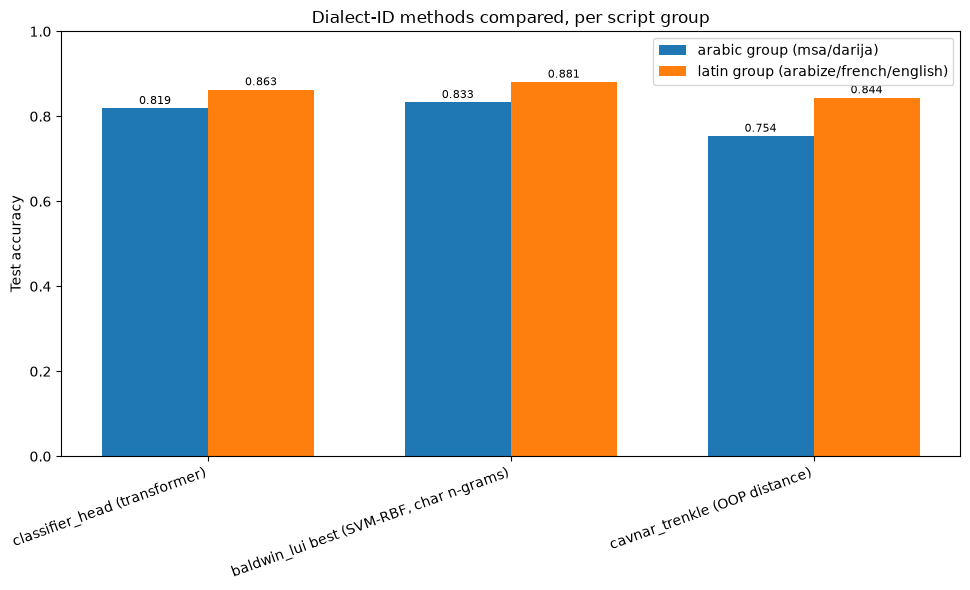

In [7]:
OTHER_METHODS = {
    # (arabic group accuracy, latin group accuracy)
    "word_cluster (unsupervised)": (None, None),  # reported as a single 5-class cluster-scored number, not per-group -- omitted here
    "classifier_head (transformer)": (0.819, 0.863),
    "baldwin_lui best (SVM-RBF, char n-grams)": (0.833, 0.881),
}

this_method = {"cavnar_trenkle (OOP distance)": (results["arabic"]["accuracy"], results["latin"]["accuracy"])}
all_methods = {**OTHER_METHODS, **this_method}

fig, ax = plt.subplots(figsize=(10, 6))
names = [k for k, v in all_methods.items() if v[0] is not None]
arabic_vals = [all_methods[k][0] for k in names]
latin_vals = [all_methods[k][1] for k in names]
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, arabic_vals, width, label="arabic group (msa/darija)")
ax.bar(x + width / 2, latin_vals, width, label="latin group (arabize/french/english)")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1)
ax.set_title("Dialect-ID methods compared, per script group")
ax.legend()
for i, (a, l) in enumerate(zip(arabic_vals, latin_vals)):
    ax.text(i - width / 2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, l + 0.01, f"{l:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
